# Laboratorio 1 - Exploración, preparación y regresión lineal

## 1. Comprensión y carga de los datos

En esta primera etapa se cargan los conjuntos de entrenamiento y prueba, junto con el diccionario de datos. El objetivo es comprender la estructura de los archivos antes de realizar cualquier transformación o corrección.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
datos = pd.read_csv("data/Datos Lab 1.csv")
datos_test = pd.read_csv("data/Datos Test Lab 1.csv")
diccionario = pd.read_excel("data/Diccionario de datos.xlsx")

In [3]:
print("Dimensiones entrenamiento:", datos.shape)
print("Dimensiones test:", datos_test.shape)
print("Dimensiones diccionario:", diccionario.shape)

Dimensiones entrenamiento: (2576, 27)
Dimensiones test: (364, 26)
Dimensiones diccionario: (27, 3)


In [4]:
datos.head()

,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,...,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,estacion_anio,mes,sector_viento,temp_max_manana
0,2009-01-01,999.1456,996.50,1000.87,1.3993,0.910860,0.875000,94.8,1.7650,0.7786,...,-0.3618,-0.0223,183.5308,143.0,2009.0,1.0,invierno,January,S,-2.12
1,2009-01-02,999.6006,997.93,1002.65,1.5039,0.920868,86.600000,96.3,2.7588,1.4195,...,0.4267,0.3689,40.8436,144.0,2009.0,2.0,invierno,JULY,NE,-0.82
2,2009-01-03,998.5486,993.05,1002.49,3.1304,76.458100,48.390000,93.9,15.1796,1.2509,...,-0.6993,-0.5268,216.9916,144.0,2009.0,3.0,invierno,January,SO,-0.63
3,2009-01-04,988.5107,985.12,992.93,2.3223,89.417400,97.946704,NaN,4.4904,1.7204,...,-1.1268,-1.0413,222.7419,144.0,2009.0,4.0,invierno,JANUARY,SO,-1.44
4,2009-01-05,990.4057,NaN,997.54,4.2315,86.260400,74.600000,93.2,5.3922,3.8003,...,2.6275,0.2874,6.2418,NaN,2009.0,5.0,East,January,N,-10.88


In [5]:
datos_test.head()

,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,...,rafaga_desv,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,estacion_anio,mes,sector_viento
0,01.01.2016,998.9860,995.57,1000.60,1.1082,96.1493,90.8,98.7,2.0034,0.9649,...,0.8415,-0.8328,0.0927,173.6501,144,2016,1,invierno,January,S
1,02.01.2016,991.4241,989.27,995.51,1.9413,92.3236,85.8,96.8,2.6562,1.9886,...,1.3604,1.1161,0.6688,30.9301,144,2016,2,invierno,January,NE
2,03.01.2016,984.0232,974.12,989.39,4.5841,83.6056,73.9,94.7,6.9967,2.4992,...,1.2558,-0.7923,1.2638,122.0847,144,2016,3,invierno,January,SE
3,04.01.2016,968.2449,966.52,974.02,1.9034,85.4688,75.5,93.8,5.8148,2.0932,...,1.4544,-1.6217,0.7020,156.5944,144,2016,4,invierno,January,SE
4,05.01.2016,970.0099,967.85,972.90,1.6668,94.3521,92.0,96.8,1.4253,1.8380,...,0.7284,1.6549,0.7109,23.2458,144,2016,5,invierno,January,NE


In [6]:
diccionario

,variable,tipo,descripcion
0,fecha,texto,"Fecha de la observación, en formato día.mes.año."
1,presion_media,numérico,Presión atmosférica media del día (mbar).
2,presion_min,numérico,Presión atmosférica mínima del día (mbar).
3,presion_max,numérico,Presión atmosférica máxima del día (mbar).
4,presion_desv,numérico,Desviación típica de la presión durante el día...
5,humedad_media,numérico,Humedad relativa media del día (%).
6,humedad_min,numérico,Humedad relativa mínima del día (%).
7,humedad_max,numérico,Humedad relativa máxima del día (%).
8,humedad_desv,numérico,Desviación típica de la humedad relativa (%).
9,viento_media,numérico,Velocidad media del viento durante el día (m/s).


In [7]:
columnas_entrenamiento = set(datos.columns)- set(datos_test.columns)
columnas_entrenamiento

{'temp_max_manana'}

### Variable objetivo

La variable objetivo del problema es `temp_max_manana`, correspondiente a la temperatura máxima del día siguiente en grados Celsius.

Por lo tanto, se trata de un problema de aprendizaje supervisado de regresión, ya que se dispone de una variable objetivo numérica continua en el conjunto de entrenamiento.

Eso está alineado con la definición del curso: una tarea de regresión busca aprender una función h: R^d -> R para predecir una respuesta continua.

In [8]:
datos.info()

<class 'pandas.DataFrame'>
RangeIndex: 2576 entries, 0 to 2575
Data columns (total 27 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   fecha              2504 non-null   str    
 1   presion_media      2501 non-null   float64
 2   presion_min        2502 non-null   float64
 3   presion_max        2512 non-null   float64
 4   presion_desv       2496 non-null   float64
 5   humedad_media      2502 non-null   float64
 6   humedad_min        2496 non-null   float64
 7   humedad_max        2490 non-null   float64
 8   humedad_desv       2515 non-null   float64
 9   viento_media       2490 non-null   float64
 10  viento_min         2485 non-null   float64
 11  viento_max         2495 non-null   float64
 12  viento_desv        2504 non-null   float64
 13  rafaga_media       2498 non-null   float64
 14  rafaga_min         2504 non-null   float64
 15  rafaga_max         2503 non-null   float64
 16  rafaga_desv        2497 non-null   

In [9]:
datos_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 364 entries, 0 to 363
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   fecha              364 non-null    str    
 1   presion_media      364 non-null    float64
 2   presion_min        364 non-null    float64
 3   presion_max        364 non-null    float64
 4   presion_desv       364 non-null    float64
 5   humedad_media      364 non-null    float64
 6   humedad_min        364 non-null    float64
 7   humedad_max        364 non-null    float64
 8   humedad_desv       364 non-null    float64
 9   viento_media       364 non-null    float64
 10  viento_min         364 non-null    float64
 11  viento_max         364 non-null    float64
 12  viento_desv        364 non-null    float64
 13  rafaga_media       364 non-null    float64
 14  rafaga_min         364 non-null    float64
 15  rafaga_max         364 non-null    float64
 16  rafaga_desv        364 non-null    fl

### Descripción inicial de los conjuntos

El conjunto de entrenamiento contiene 2.576 observaciones y 27 variables, mientras que el conjunto de prueba contiene 364 observaciones y 26 variables.

La diferencia corresponde a `temp_max_manana`, que únicamente está disponible en el conjunto de entrenamiento y constituye la variable objetivo del problema.

Cada observación representa información meteorológica agregada de un día. Las características incluyen medidas de presión atmosférica, humedad, velocidad y dirección del viento, ráfagas e información temporal.

Debido a que `temp_max_manana` es una variable numérica continua, el problema corresponde a una tarea de regresión dentro del aprendizaje supervisado.

## 2. Exploración y diagnóstico de calidad de los datos

A partir de la descripción inicial, se realiza un perfilamiento más detallado del conjunto de entrenamiento. El objetivo es comprender la distribución de las variables e identificar problemas de completitud, unicidad, consistencia y validez antes de realizar cualquier corrección.

En esta etapa los problemas únicamente se diagnostican. Las modificaciones sobre los datos se realizarán posteriormente en la etapa de preparación.

In [10]:
#2.1 — Estadísticas descriptivas

# Obtener estadísticas descriptivas de las variables numéricas.
# Revisar las variables categóricas mediante frecuencias.
# Comparar los resultados con el diccionario de datos.
# Identificar valores o escalas que parezcan inconsistentes.

display(datos.describe())
display(datos.describe(include='object'))

# Al comparar con el diccionario de datos resaltan dos problemas de escala/validez
# que se profundizarán en 2.6: presion_media alcanza valores cercanos a 9800-9900
# (mbar), muy por encima del resto de observaciones (~950-1015), y humedad_media /
# humedad_min presentan un mínimo cercano a 0 pese a definirse como porcentaje
# (0-100), lo que sugiere que algunos registros quedaron en escala de proporción.


,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,viento_min,...,rafaga_min,rafaga_max,rafaga_desv,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,temp_max_manana
count,2501.000000,2502.000000,2512.000000,2496.000000,2502.000000,2496.000000,2490.000000,2515.000000,2490.000000,2485.000000,...,2504.000000,2503.000000,2497.000000,2496.000000,2512.000000,2497.000000,2499.000000,2490.000000,2508.000000,2481.000000
mean,1010.494271,986.684409,991.704244,1.752041,52.413586,45.094067,90.236582,10.606821,3.814103,1.417799,...,-2.639322,6.946058,-5.763253,-1.128463,-0.410159,172.104573,144.090836,2011.995582,182.690989,13.863309
std,435.334494,8.927138,7.726906,1.215931,35.975384,30.196163,10.647237,5.481338,3.307402,3.960650,...,199.861693,3.237379,75.258134,25.065084,1.147218,86.102348,4.107365,1.999694,105.529469,9.296199
min,948.996000,913.600000,951.940000,0.226900,0.004663,0.237700,27.020000,0.000000,0.000000,0.000000,...,-9999.000000,0.000000,-232.260000,-1250.463300,-3.718500,0.000000,90.000000,2009.000000,1.000000,-15.230000
25%,984.287800,981.371333,987.070000,0.899050,0.869060,1.011790,88.025000,6.082100,1.655350,0.230000,...,0.440000,4.803198,1.002100,-1.640625,-1.236475,91.303500,144.000000,2010.000000,91.000000,7.310000
50%,989.452800,987.070000,991.935000,1.444550,68.558100,49.670000,93.300000,10.199800,2.463400,0.440000,...,0.660000,6.690000,1.461100,-0.564300,-0.356000,199.568500,144.000000,2012.000000,182.500000,14.310000
75%,994.469000,992.567500,996.782500,2.254800,80.562600,67.665000,96.600000,14.722200,4.880505,0.960000,...,1.120000,8.850000,2.008800,0.241525,0.316275,227.101700,144.000000,2014.000000,274.250000,20.460000
max,9939.918000,1012.320198,1013.940000,12.397500,100.000000,103.311405,100.000000,26.341600,24.753600,45.184956,...,19.895916,23.500000,3471.027800,4.809900,4.713900,359.796700,287.000000,2015.000000,366.000000,63.050000


C:\Users\jfoch\AppData\Local\Temp\ipykernel_21536\2199386499.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(datos.describe(include='object'))


,fecha,estacion_anio,mes,sector_viento
count,2504,2488,2488,2505
unique,2486,28,61,33
top,2009-01-22,primavera,May,SO
freq,2,517,127,695


### 2.2. Completitud

Se analiza la presencia de valores faltantes en cada variable del conjunto de entrenamiento. En esta sección únicamente se cuantificará el problema; la estrategia de tratamiento se determinará durante la preparación de los datos.

In [11]:
faltantes = datos.isna().sum()

porcentaje_faltantes = (
    datos.isna().mean() * 100
).round(2)

resumen_faltantes = pd.DataFrame({
    "faltantes": faltantes,
    "porcentaje": porcentaje_faltantes
})

resumen_faltantes = (
    resumen_faltantes
    .sort_values("porcentaje", ascending=False)
)

display(resumen_faltantes)

# Variables con al menos un valor faltante.
resumen_faltantes[resumen_faltantes["faltantes"] > 0]


,faltantes,porcentaje
temp_max_manana,95,3.69
viento_min,91,3.53
estacion_anio,88,3.42
mes,88,3.42
anio,86,3.34
humedad_max,86,3.34
viento_media,86,3.34
viento_max,81,3.14
humedad_min,80,3.11
viento_norte,80,3.11


,faltantes,porcentaje
temp_max_manana,95,3.69
viento_min,91,3.53
estacion_anio,88,3.42
mes,88,3.42
anio,86,3.34
humedad_max,86,3.34
viento_media,86,3.34
viento_max,81,3.14
humedad_min,80,3.11
viento_norte,80,3.11


### 2.3. Unicidad

Se verifica si existen registros repetidos en el conjunto de entrenamiento. Los duplicados pueden representar errores de almacenamiento o distintas observaciones reales, por lo que no deben eliminarse automáticamente sin analizar su significado.

In [12]:
# Buscar filas completamente duplicadas.
print("Duplicados completos (todas las columnas iguales):", datos.duplicated(keep=False).sum())

# Revisar si existen fechas repetidas, ignorando registros con fecha faltante
# (dos fechas faltantes no son una fecha "repetida").
print("Registros con fecha repetida:", datos.loc[datos["fecha"].notna(), "fecha"].duplicated(keep=False).sum())

fechas_repetidas = datos[
    datos["fecha"].notna() & datos["fecha"].duplicated(keep=False)
].sort_values("fecha")

fechas_repetidas

# Analizar si una fecha repetida corresponde realmente a un duplicado lógico.
# No se elimina ningún registro en esta etapa: la estrategia de tratamiento de
# duplicados se definirá en la preparación de los datos.


Duplicados completos (todas las columnas iguales): 8
Registros con fecha repetida: 36


,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,...,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,estacion_anio,mes,sector_viento,temp_max_manana
21,2009-01-22,9784.115000,971.48000,983.54,3.9853,86.731100,69.1100,97.6,9.7926,10.09692,...,-2.7229,-0.1899,183.9897,144.0,2009.0,22.0,verano,octubre,S,5.770000
2563,2009-01-22,9784.115000,971.48000,983.54,3.9853,86.731100,69.1100,97.6,9.7926,10.09692,...,-2.7229,-0.1899,183.9897,144.0,2009.0,22.0,verano,octubre,S,5.770000
63,2009-03-05,959.860700,958.67000,962.54,0.8964,94.294400,86.0000,97.8,2.8296,1.29080,...,1.1131,0.1826,9.3166,144.0,2009.0,64.0,primavera,July,N,5.370000
2574,2009-03-05,959.860700,958.67000,962.54,0.8964,NaN,86.0000,97.8,2.8296,1.29080,...,1.1131,0.1826,9.3166,144.0,2009.0,64.0,primavera,July,N,5.956009
121,2009-05-02,998.118900,995.99000,999.41,0.9205,77.500000,51.0900,99.6,18.9020,1.84440,...,NaN,0.4668,23.7431,144.0,NaN,122.0,primavera,october,NaN,20.890000
2568,2009-05-02,998.855231,995.99000,999.41,0.9205,77.500000,51.0900,99.6,18.9020,1.84440,...,1.0611,0.4668,23.7431,144.0,2009.0,122.0,primavera,october,NE,20.890000
2575,2009-12-08,983.849000,979.45000,991.40,3.7836,1.021309,0.8010,96.8,5.9641,4.53492,...,-0.6218,NaN,233.2095,144.0,2009.0,342.0,verano,Enero,SO,7.120000
341,2009-12-08,983.849000,979.45000,991.40,3.7836,0.877951,0.8010,96.8,5.9641,4.53492,...,-0.6218,-0.8314,233.2095,144.0,2009.0,342.0,verano,Enero,SO,7.120000
2566,2010-08-14,991.272748,989.22000,991.29,0.4346,84.386400,65.1200,95.7,9.4681,1.70860,...,0.7872,0.6511,39.5952,144.0,2010.0,226.0,verano,August,NE,19.500000
590,2010-08-14,990.482800,989.22000,991.29,0.4346,84.386400,65.1200,95.7,9.4681,1.70860,...,0.7872,0.6511,39.5952,144.0,2010.0,226.0,verano,August,NE,19.500000


### 2.4. Consistencia de variables categóricas

Se revisan las categorías observadas en las variables de texto para detectar diferentes representaciones de una misma categoría, errores de escritura o valores incompatibles con el significado definido en el diccionario.

In [13]:
#2.4 — Consistencia de variables categóricas

import unicodedata


def normalizar_texto(serie):
    """Minúsculas, sin espacios en los extremos y sin tildes, para comparar categorías."""
    return (
        serie.astype(str)
        .str.strip()
        .str.lower()
        .map(lambda s: "".join(c for c in unicodedata.normalize("NFKD", s) if not unicodedata.combining(c)))
    )


for col in ["estacion_anio", "mes", "sector_viento"]:
    print(f"--- {col}: {datos[col].nunique(dropna=True)} categorías únicas (crudas) ---")
    print(datos[col].value_counts(dropna=False))

    normalizado = normalizar_texto(datos[col].dropna())
    print(f"--- {col}: {normalizado.nunique()} categorías tras normalizar (minúsculas, sin espacios ni tildes) ---")
    print(sorted(normalizado.unique()))
    print()

# Hallazgos:
# - sector_viento: las 33 categorías crudas colapsan en 8 puntos cardinales reales
#   (N, S, E, O, NE, NO, SE, SO) una vez normalizadas; todas son mapeables al
#   dominio esperado (sin valores fuera de dominio).
# - mes: 61 categorías crudas (mezcla de español/inglés, nombre completo/abreviado,
#   mayúsculas/minúsculas) que sí corresponden todas a alguno de los 12 meses,
#   pero con muchísima variación de escritura.
# - estacion_anio: además de mezclar español/inglés, mayúsculas/minúsculas y
#   errores de escritura (p. ej. "Inverano", "invernio", "berano", "verno"),
#   contiene categorías que no corresponden a ninguna estación real del dominio
#   ("East", "Estacion_Desconocida", "VERANO_INVIERNO").


--- estacion_anio: 28 categorías únicas (crudas) ---
estacion_anio
primavera               517
invierno                511
otono                   500
verano                  487
NaN                      88
Inverano                 71
Estacion_Desconocida     63
VERANO_INVIERNO          60
East                     48
VERANO                   19
autumn                   18
primaveraa               17
berano                   17
fall                     15
winter                   15
verno                    14
Otoño                    12
otoño                    11
invernio                 11
Primavera                10
PRIMAVERA                10
invierno                  9
INVIERNO                  9
Verano                    9
Invierno                  9
OTONO                     8
primav                    6
spring                    6
summer                    6
Name: count, dtype: int64
--- estacion_anio: 18 categorías tras normalizar (minúsculas, sin espacios ni tildes) ---
['aut

### 2.5. Consistencia de la información temporal

El conjunto contiene distintas representaciones temporales: `fecha`, `anio`, `dia_del_anio`, `mes` y `estacion_anio`.

Se verificará que estas variables representen de manera coherente la misma fecha y se analizará si algunas contienen información redundante.

In [15]:
#2.5 — Consistencia de la información temporal

# Formato de fecha usado en cada conjunto.
print("Formato en entrenamiento (ejemplos):", datos["fecha"].dropna().head(3).tolist())
print("Formato en el conjunto de prueba final (ejemplos):", datos_test["fecha"].dropna().head(3).tolist())
# -> entrenamiento usa 'AAAA-MM-DD' (ISO) y el conjunto de prueba usa 'DD.MM.AAAA'.
# Se documenta la diferencia de formato; no se modifica ningún dato en esta etapa
# (la conversión se hará, si es necesaria, en la preparación de los datos).

fecha_train = pd.to_datetime(datos["fecha"], format="%Y-%m-%d", errors="coerce")
fecha_test = pd.to_datetime(datos_test["fecha"], format="%d.%m.%Y", errors="coerce")

print("Fechas de entrenamiento no interpretables con el formato detectado:",
      ((datos["fecha"].notna()) & (fecha_train.isna())).sum())
print("Fechas de prueba no interpretables con el formato detectado:",
      ((datos_test["fecha"].notna()) & (fecha_test.isna())).sum())

# Comparar fecha con anio y con dia_del_anio.
mask_anio = fecha_train.notna() & datos["anio"].notna()
print("Desacuerdos entre fecha y anio:",
      (fecha_train[mask_anio].dt.year != datos.loc[mask_anio, "anio"]).sum(), "de", mask_anio.sum())

mask_dia = fecha_train.notna() & datos["dia_del_anio"].notna()
print("Desacuerdos entre fecha y dia_del_anio:",
      (fecha_train[mask_dia].dt.dayofyear != datos.loc[mask_dia, "dia_del_anio"]).sum(), "de", mask_dia.sum())

# Comparar fecha con mes (normalizando nombres completos y abreviados, en español e inglés).
meses_map = {
    "enero": 1, "ene": 1, "jan": 1, "january": 1,
    "febrero": 2, "feb": 2, "february": 2,
    "marzo": 3, "mar": 3, "march": 3,
    "abril": 4, "abr": 4, "apr": 4, "april": 4,
    "mayo": 5, "may": 5,
    "junio": 6, "jun": 6, "june": 6,
    "julio": 7, "jul": 7, "july": 7,
    "agosto": 8, "ago": 8, "aug": 8, "august": 8,
    "septiembre": 9, "setiembre": 9, "sep": 9, "sept": 9, "september": 9,
    "octubre": 10, "oct": 10, "october": 10,
    "noviembre": 11, "nov": 11, "november": 11,
    "diciembre": 12, "dic": 12, "dec": 12, "december": 12,
}
mes_num = datos["mes"].dropna().str.strip().str.lower().map(meses_map)
print("Valores de mes que no corresponden a ningún nombre de mes conocido:",
      sorted(mes_num[mes_num.isna()].index.map(lambda i: datos.loc[i, "mes"]).unique()))

mask_mes = fecha_train.notna() & mes_num.notna()
print("Desacuerdos entre fecha y mes:",
      (fecha_train[mask_mes.index[mask_mes]].dt.month != mes_num[mask_mes]).sum(), "de", int(mask_mes.sum()))

# Comparar fecha con estacion_anio: se reutiliza normalizar_texto (definida en 2.4)
# y se construye la estación "esperada" para cada mes a partir de la moda empírica
# entre los registros ya normalizados, sin asumir a priori una convención de
# hemisferio.
estacion_map = {
    "invierno": "invierno", "inverano": "invierno", "invernio": "invierno", "winter": "invierno",
    "primavera": "primavera", "primaveraa": "primavera", "primav": "primavera", "spring": "primavera",
    "verano": "verano", "berano": "verano", "verno": "verano", "summer": "verano",
    "otono": "otono", "autumn": "otono", "fall": "otono",
}
estacion_norm = normalizar_texto(datos["estacion_anio"].dropna())
estacion_canon = estacion_norm.map(estacion_map)

comparables = pd.DataFrame({"mes_num": mes_num, "estacion_canon": estacion_canon}).dropna()
moda_por_mes = comparables.groupby("mes_num")["estacion_canon"].agg(lambda s: s.value_counts().idxmax())
esperado = comparables["mes_num"].map(moda_por_mes)
print("Desacuerdos entre estacion_anio (normalizada) y la estación esperada según el mes:",
      (comparables["estacion_canon"] != esperado).sum(), "de", len(comparables))

# Conclusión: anio y dia_del_anio son plenamente consistentes con fecha (0
# desacuerdos). mes y estacion_anio, en cambio, presentan una altísima tasa de
# desacuerdo con la fecha real y son derivables directamente de ella, por lo que
# resultan redundantes con fecha.


Formato en entrenamiento (ejemplos): ['2009-01-01', '2009-01-02', '2009-01-03']
Formato en el conjunto de prueba final (ejemplos): ['01.01.2016', '02.01.2016', '03.01.2016']
Fechas de entrenamiento no interpretables con el formato detectado: 0
Fechas de prueba no interpretables con el formato detectado: 0
Desacuerdos entre fecha y anio: 0 de 2421
Desacuerdos entre fecha y dia_del_anio: 0 de 2437
Valores de mes que no corresponden a ningún nombre de mes conocido: []
Desacuerdos entre fecha y mes: 1136 de 2417
Desacuerdos entre estacion_anio (normalizada) y la estación esperada según el mes: 929 de 2239


### 2.6. Validez de las variables numéricas

Se revisará si los valores numéricos respetan los rangos y unidades definidos en el diccionario.

Los valores extremos no se considerarán automáticamente errores. Primero se distinguirá entre observaciones poco frecuentes pero plausibles y valores incompatibles con el dominio de la variable.

In [14]:
#2.6 — Validez de las variables numéricas

numeric_cols = datos.select_dtypes("number").columns
display(datos[numeric_cols].agg(["min", "max"]).T)

# Contrastando estos rangos con las unidades y descripciones del diccionario de
# datos, se identifican valores incompatibles con el dominio físico esperado.
# Ninguno se corrige ni se elimina en esta etapa: solo se documentan como
# candidatos a tratar en la preparación de los datos.

print("presion_media > 2000 mbar (posible error de escala/punto decimal):",
      (datos["presion_media"] > 2000).sum())

print("humedad_media <= 1 (posible proporción en vez de porcentaje):",
      (datos["humedad_media"] <= 1).sum())
print("humedad_min <= 1 (mismo problema de escala):",
      (datos["humedad_min"] <= 1).sum())
print("humedad_min > 100% (fuera del dominio 0-100):",
      (datos["humedad_min"] > 100).sum())

print("rafaga_desv < 0 (una desviación estándar no puede ser negativa):",
      (datos["rafaga_desv"] < 0).sum())
print("rafaga_min == -9999 (posible código centinela de dato faltante):",
      (datos["rafaga_min"] == -9999).sum())

print("viento_desv > 100 (magnitud implausible para una desviación de velocidad de viento):",
      (datos["viento_desv"] > 100).sum())
print("viento_norte con magnitud extrema (< -100):",
      (datos["viento_norte"] < -100).sum())

print("direccion_viento fuera de [0, 360):",
      ((datos["direccion_viento"] < 0) | (datos["direccion_viento"] >= 360)).sum())


,min,max
presion_media,948.996000,9939.918000
presion_min,913.600000,1012.320198
presion_max,951.940000,1013.940000
presion_desv,0.226900,12.397500
humedad_media,0.004663,100.000000
humedad_min,0.237700,103.311405
humedad_max,27.020000,100.000000
humedad_desv,0.000000,26.341600
viento_media,0.000000,24.753600
viento_min,0.000000,45.184956


presion_media > 2000 mbar (posible error de escala/punto decimal): 6
humedad_media <= 1 (posible proporción en vez de porcentaje): 776
humedad_min <= 1 (mismo problema de escala): 621
humedad_min > 100% (fuera del dominio 0-100): 23
rafaga_desv < 0 (una desviación estándar no puede ser negativa): 258
rafaga_min == -9999 (posible código centinela de dato faltante): 1
viento_desv > 100 (magnitud implausible para una desviación de velocidad de viento): 132
viento_norte con magnitud extrema (< -100): 1
direccion_viento fuera de [0, 360): 0


### 2.7. Distribuciones y relaciones entre variables

Se estudiará la forma de las distribuciones y las relaciones entre las características y la variable objetivo con el propósito de comprender mejor el problema y formular hipótesis antes de construir los modelos.

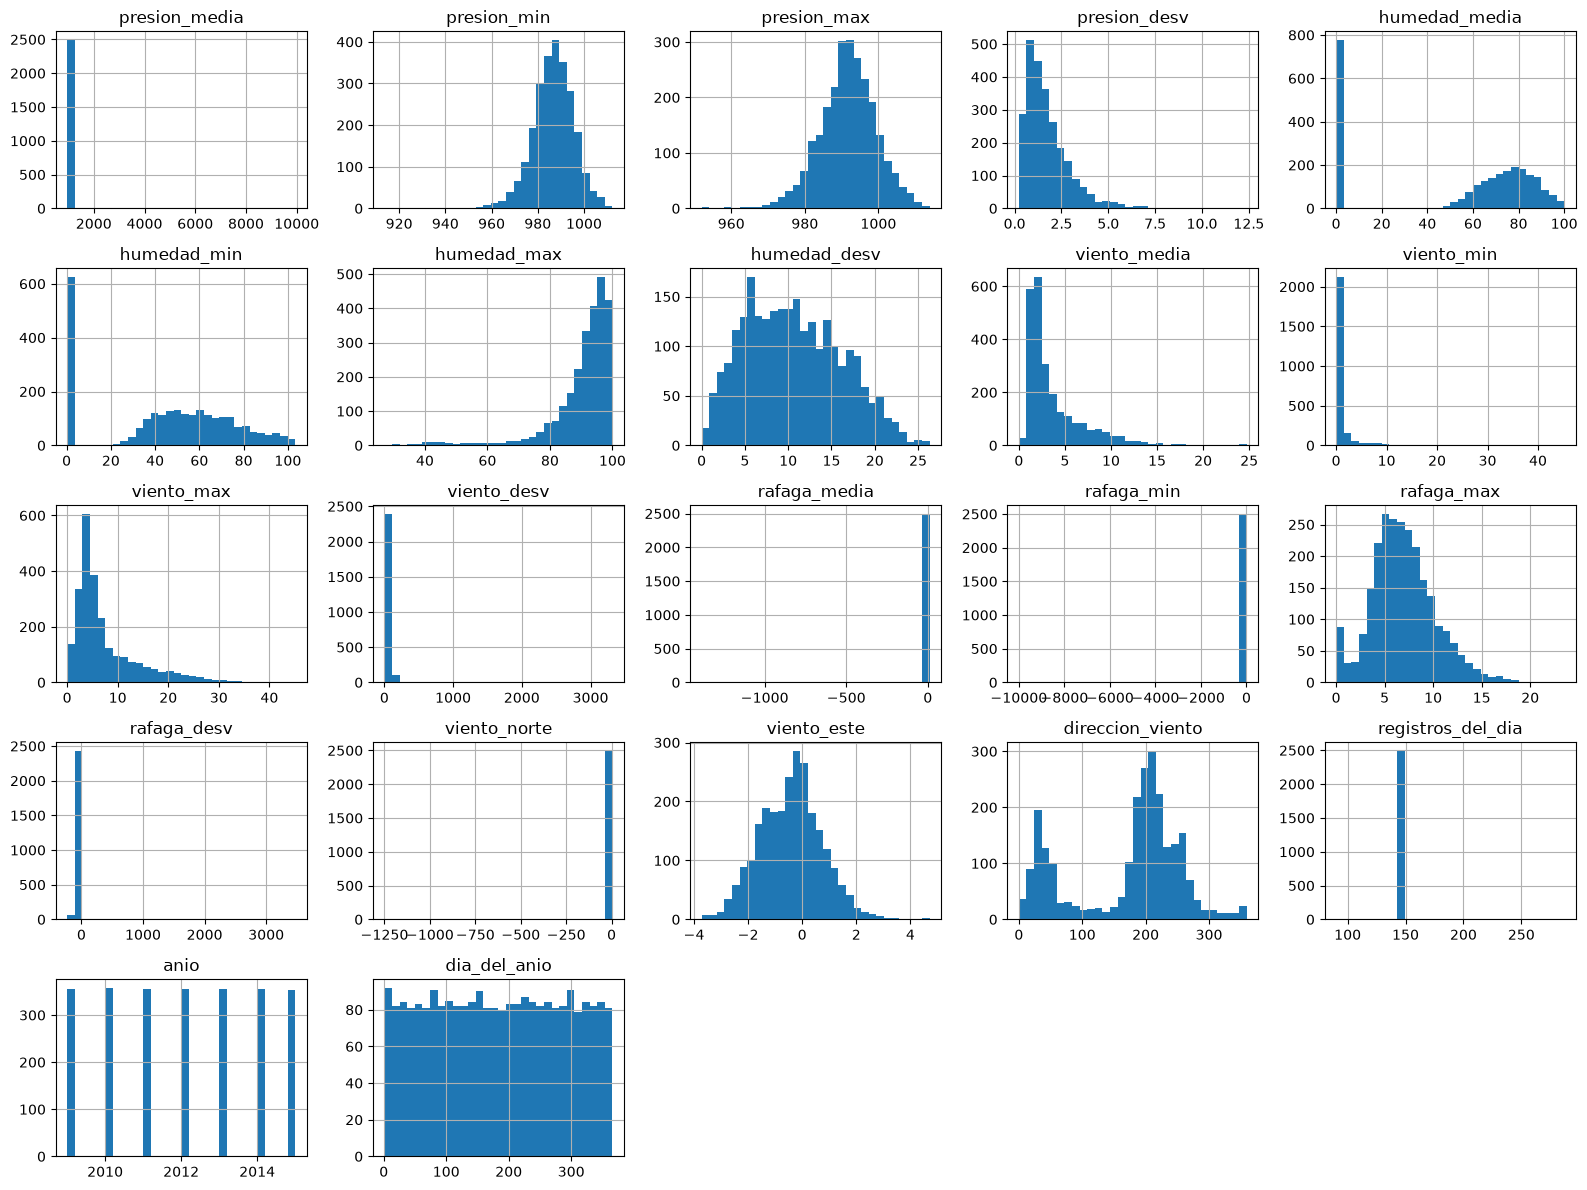

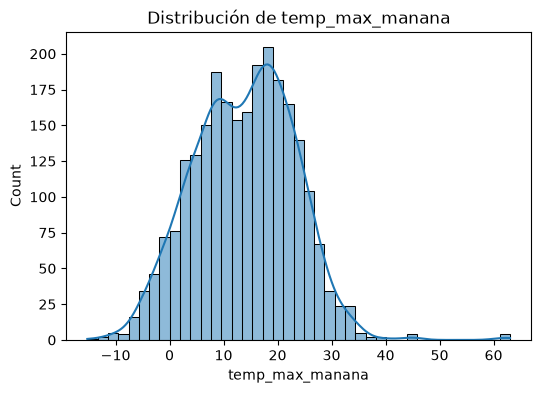

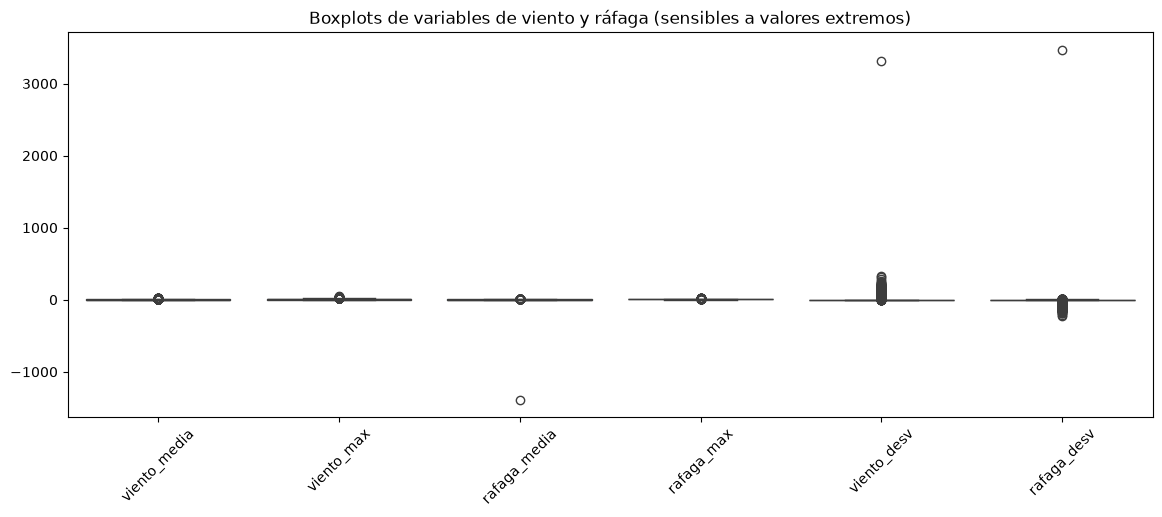

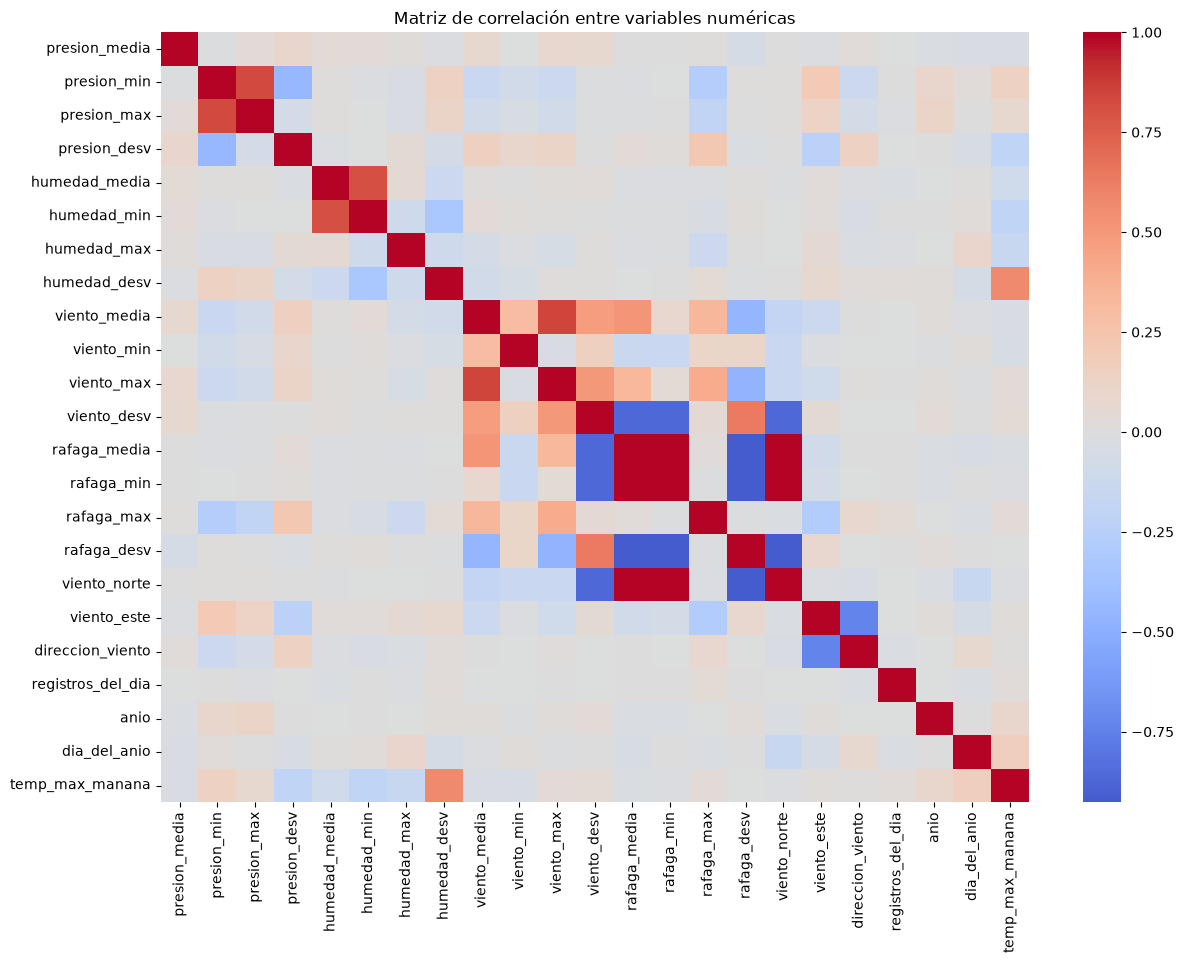

temp_max_manana      1.000000
humedad_desv         0.571459
dia_del_anio         0.165812
presion_min          0.141860
anio                 0.092718
presion_max          0.070861
viento_desv          0.040129
viento_max           0.031348
rafaga_max           0.030527
registros_del_dia    0.025923
viento_este          0.015941
direccion_viento     0.007824
rafaga_desv         -0.007027
rafaga_min          -0.019087
viento_norte        -0.020881
rafaga_media        -0.024158
presion_media       -0.032249
viento_media        -0.035994
viento_min          -0.039749
humedad_media       -0.098139
humedad_max         -0.155211
presion_desv        -0.199890
humedad_min         -0.203226
Name: temp_max_manana, dtype: float64

In [16]:
#2.7 — Distribuciones y relaciones entre variables

numeric_cols = datos.select_dtypes("number").columns.drop("temp_max_manana")

datos[numeric_cols].hist(figsize=(16, 12), bins=30)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
sns.histplot(datos["temp_max_manana"].dropna(), kde=True)
plt.title("Distribución de temp_max_manana")
plt.show()

plt.figure(figsize=(14, 5))
sns.boxplot(data=datos[["viento_media", "viento_max", "rafaga_media", "rafaga_max",
                         "viento_desv", "rafaga_desv"]])
plt.xticks(rotation=45)
plt.title("Boxplots de variables de viento y ráfaga (sensibles a valores extremos)")
plt.show()

plt.figure(figsize=(14, 10))
correlaciones = datos.select_dtypes("number").corr()
sns.heatmap(correlaciones, cmap="coolwarm", center=0, annot=False)
plt.title("Matriz de correlación entre variables numéricas")
plt.show()

correlaciones["temp_max_manana"].sort_values(ascending=False)

# temp_max_manana muestra una distribución razonablemente simétrica. Los grupos
# de variables de presión (media/min/max/desv) y de humedad están fuertemente
# correlacionados entre sí, lo que sugiere redundancia informativa entre ellas;
# lo mismo ocurre con viento_media/viento_max y rafaga_media/rafaga_max.


### 2.8. Hallazgos de la exploración

Los resultados anteriores se resumen para establecer qué correcciones y transformaciones serán necesarias antes del modelado.

Hallazgos de la exploración (conjunto de entrenamiento):

- Completitud: todas las variables presentan valores faltantes, entre ~2.4% y
  ~3.7% de las observaciones; no hay una variable con un porcentaje extremo de
  faltantes que obligue a descartarla por completo.
- Unicidad: existen filas completamente duplicadas y registros con la misma
  fecha; no se eliminó ningún registro en esta etapa, queda pendiente decidir si
  son duplicados lógicos o mediciones distintas.
- Consistencia categórica: estacion_anio, mes y sector_viento repiten la misma
  categoría escrita de múltiples formas (mayúsculas/minúsculas, español/inglés,
  abreviaturas, tildes, espacios); estacion_anio además contiene valores que no
  corresponden a ninguna estación real ("East", "Estacion_Desconocida",
  "VERANO_INVIERNO").
- Consistencia temporal: anio y dia_del_anio son plenamente coherentes con
  fecha. mes y estacion_anio, en cambio, presentan una altísima tasa de
  desacuerdo con la fecha real y son derivables directamente de ella, por lo que
  resultan redundantes.
- Validez numérica: se encontraron valores incompatibles con el dominio físico
  esperado, como presion_media por encima de 2000 mbar (posible error de
  escala/punto decimal), humedad_media/humedad_min en escala de proporción
  (0-1) en vez de porcentaje, humedad_min por encima de 100%, desviaciones
  estándar negativas en rafaga_desv, un posible código centinela (-9999) en
  rafaga_min, y magnitudes extremas en viento_norte y viento_desv.
- Distribuciones y relaciones: temp_max_manana tiene una distribución razonable
  y sin problemas evidentes. Las variables de presión (media/min/max/desv), de
  humedad y de viento/ráfaga están fuertemente correlacionadas entre sí, lo que
  sugiere redundancia informativa dentro de cada grupo.
- Variables con señal aparente para predecir temp_max_manana: las variables de
  presión y humedad muestran la correlación más visible con el objetivo, y la
  información temporal (fecha/anio/dia_del_anio, una vez unificado el formato
  entre entrenamiento y prueba) también es una candidata razonable.

## 3. Preparación de los datos

La preparación se realiza a partir de los problemas identificados durante la exploración. Cada transformación se justificará de acuerdo con el tipo de variable, el porcentaje de datos afectados y su significado dentro del problema.

Para evitar fuga de datos, las transformaciones que requieran estimar parámetros a partir de los datos se ajustarán únicamente utilizando el conjunto de entrenamiento.

### 3.1. Corrección de consistencia y validez

Primero se aplicarán únicamente transformaciones determinísticas, es decir, aquellas que dependen de reglas conocidas del dominio y no de estadísticas calculadas a partir de toda la muestra.

In [20]:
### TODO 3.1
"""
Según los hallazgos anteriores:

- normalizar categorías;
- corregir representaciones equivalentes;
- convertir `fecha` al tipo temporal adecuado;
- resolver valores claramente inválidos cuando exista una regla justificable;
- resolver duplicados lógicos si existen.
"""

'\nSegún los hallazgos anteriores:\n\n- normalizar categorías;\n- corregir representaciones equivalentes;\n- convertir `fecha` al tipo temporal adecuado;\n- resolver valores claramente inválidos cuando exista una regla justificable;\n- resolver duplicados lógicos si existen.\n'

### 3.2. Tratamiento de observaciones sin variable objetivo

Las observaciones que no contienen `temp_max_manana` no pueden utilizarse directamente para entrenar un modelo supervisado, porque no existe un valor real contra el cual calcular el error.

In [21]:
### TODO 3.2
"""
- Identificar las filas con `temp_max_manana` faltante.
- Determinar cuántas observaciones representan.
- Excluirlas del conjunto utilizado para entrenamiento y evaluación.
- Documentar la decisión.
"""

'\n- Identificar las filas con `temp_max_manana` faltante.\n- Determinar cuántas observaciones representan.\n- Excluirlas del conjunto utilizado para entrenamiento y evaluación.\n- Documentar la decisión.\n'

### 3.3. Selección y construcción de características

Se evaluará qué representación temporal utilizar en los modelos y si es conveniente construir características adicionales a partir de las variables disponibles.

Las nuevas características deberán utilizar únicamente información disponible al momento de realizar la predicción.

### TODO 3.3

- Evaluar redundancia entre `fecha`, `anio`, `dia_del_anio`, `mes` y `estacion_anio`.
- Determinar qué variables temporales conservar.
- Definir posibles nuevas características justificadas.
- Evitar construir características utilizando `temp_max_manana`.
- Evitar cualquier variable que utilice información del día siguiente.

### 3.4. Definición de características y variable objetivo

### TODO 3.4

- Definir `X`.
- Definir `y`.
- Confirmar que `temp_max_manana` no aparezca en `X`.
- Excluir variables que no deban entrar al modelo.

### 3.5. Separación entrenamiento-prueba

Antes de ajustar imputadores, escaladores, codificadores o el modelo, los datos se dividirán en entrenamiento y prueba.

Esto permite que las transformaciones aprendan sus parámetros únicamente del conjunto de entrenamiento y evita fuga de información hacia el conjunto de prueba.

In [ ]:
### TODO 3.5
"""
Realizar:

- 75 % entrenamiento.
- 25 % prueba.
- `random_state = 42`.

Después de esta separación:

- no calcular medias globales para imputar;
- no escalar usando todos los datos;
- no ajustar codificadores con prueba;
- no seleccionar transformaciones observando el rendimiento del conjunto de prueba repetidamente.
"""

### 3.6. Estrategias de preprocesamiento

In [ ]:
### TODO 3.6
"""
Definir por separado:

- variables numéricas;
- variables categóricas;
- estrategia de imputación para numéricas;
- estrategia de imputación para categóricas;
- estrategia de codificación;
- estrategia de escalado cuando corresponda.
"""